# IMDB reviews classification in Keras (RNN, LSTM, GRU, Bidirectional, Stacked (Deep))

The task is to experiment with different architectures (RNN, LSTM, GRU, Bidirectional, Stacked (Deep)), compare, draw conclusions. Rules that are being followed for a fair comparison:
- fixed vocab, maxlen, embedding dim, batch size and unit count across every run. The only difference between runs is the architecture.

## Libraries and constants

In [1]:
import gc
import os
import time

import seaborn as sns

os.environ["KERAS_BACKEND"] = "torch"

import keras
import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from utils import debug_tuner, plot_loss_acc_per_ep, seed_everything

In [2]:
# --- CONSTANTS ---
RANDOM_SEED = 42

# --- SEEDING FUNCTIONALITY ---
rng = seed_everything(RANDOM_SEED)

# for num_workers > 0 in PyTorch DataLoader, each worker will inherit the exact same random state from the main process
# This means every worker will generate the exact same "random" data augmentations. We fix this using worker_init_fn
torch_gen = torch.Generator()
torch_gen.manual_seed(RANDOM_SEED)

## Data Import, Overview, EDA, Cleaning

### Choosing VOCAB_SIZE

The task and lectures tell nothing again, we have to figure everything out ourselves. Since we don't have full raw text (and it's not NLP anyway, RNNs are largely replaced by transformers these days), I don't see any point in this search. For a real case, I would divide into tokens, count unique and sorted descending. As soon as vocabulary count start occurring only a handful of times, we truncate it. Let's imagine it happened at the value of $10,000$ here since everyone likes to stick to this size so much.

In general, `VOCAB_SIZE`, `MAX_LENGTH` and `EMBED_DIM` are not hyperparameters to be tuned during training in the same way as we do with learning rate, optimizer or epochs. They are compute knobs in the sense that raising them helps, then stops helping, then costs a lot of time and a little overfitting. We are going to choose them moderately (to be on the more optimal size), but realistically and only try to increase if the model underfits (hardly be the case for such a simple task I suppose).

`MAX_LENGTH` and `VOCAB_SIZE` are both truncation - we're deciding how much of the input to throw away. Same rule for both: keep roughly 90–95% of the content.

`EMBED_DIM` isn't truncation, it's capacity, so it saturates for a different reason: at some point extra dimensions have no more structure to encode. The rule: pick from the standard ladder (32/64/128/256) and only revisit if the model is underfitting.

In [3]:
VOCAB_SIZE = 10_000     # keep the 10k most frequent words; the rest become <OOV>

In [4]:
# ---------- 1. Load and pad ----------
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)

### Data overview

In [5]:
x_train

array([list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]),
       list([1, 194, 1153, 194, 8255, 78, 228,

In [6]:
print(f"Train targets: {np.unique(y_train)}")
print(f"Test targets: {np.unique(y_test)}")

Train targets: [0 1]
Test targets: [0 1]


The dataset is also pre-encoded, which isn't great for learning again. Not able to derive the method and try it ourselves. The research on how it's done in this dataset is below.

The text was already stripped off of any punctuation (because the dataset is very old and deleting punctuation was a cheap fix for speed) and lowercased. Then the most frequent words are determined and sorted, each word is represented via that popularity number PLUS 3 - reserved for the special tokens:
- "1" marks the start of a sequence (of a review in this case)
- "2" marks OOV words
- "0" isn't present for now, but reserved for padding

According to the docs, the target is binary, where:
- $0$ stands for negative review
- $1$ stands for positive review

### Class balance

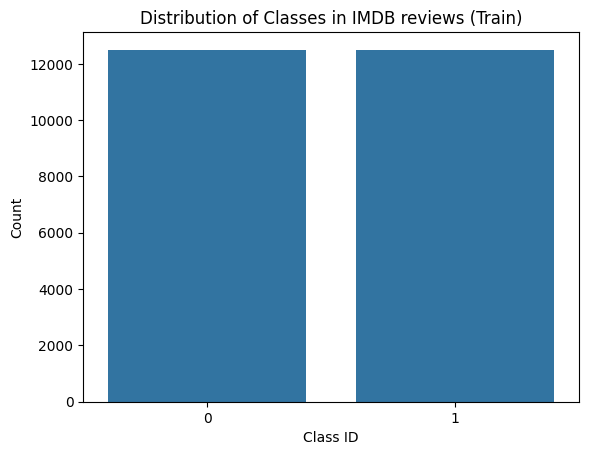

In [7]:
sns.countplot(x=y_train)
plt.title("Distribution of Classes in IMDB reviews (Train)")
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.show()

In [8]:
np.unique(y_train, return_counts=True)

(array([0, 1], dtype=int64), array([12500, 12500], dtype=int64))

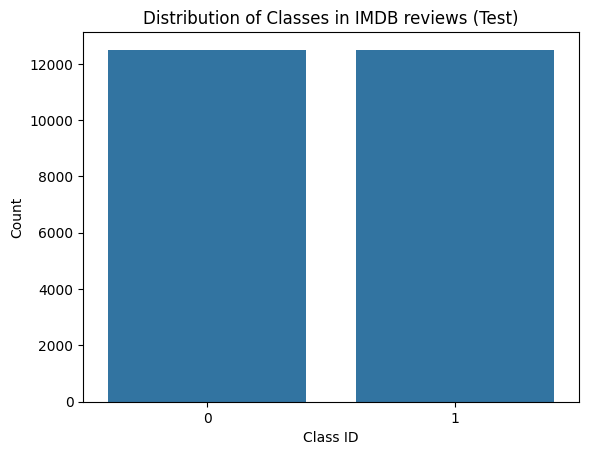

In [9]:
sns.countplot(x=y_test)
plt.title("Distribution of Classes in IMDB reviews (Test)")
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.show()

In [10]:
np.unique(y_test, return_counts=True)

(array([0, 1], dtype=int64), array([12500, 12500], dtype=int64))

The split is perfectly stratified by the target. Balanced.

### Data split

In [11]:
print(f"Reviews in train: {x_train.shape}")
print(f"Reviews in test: {x_test.shape}")

Reviews in train: (25000,)
Reviews in test: (25000,)


The ratio of the supplied split is 50/50. It is weird and doesn't reflect modern practices. Resplitting into 80/20:

In [12]:
# Combine all train and test Xs and ys
x_full = np.concatenate([x_train, x_test])
y_full = np.concatenate([y_train, y_test])

# 80/20 split into train and temp (that will be divided further), stratified by target
x_train, x_temp, y_train, y_temp = train_test_split(
    x_full,
    y_full,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y_full,
)

# 50/50 split of temp into validation and test, stratified by target
x_val, x_test, y_val, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=y_temp,
)

print("Train size:", len(x_train))
print("Val size:", len(x_val))
print("Test size:", len(x_test))

print()

print("Class balance in train:", np.unique(y_train, return_counts=True))
print("Class balance in validation:", np.unique(y_val, return_counts=True))
print("Class balance in test:", np.unique(y_test, return_counts=True))

Train size: 40000
Val size: 5000
Test size: 5000

Class balance in train: (array([0, 1], dtype=int64), array([20000, 20000], dtype=int64))
Class balance in validation: (array([0, 1], dtype=int64), array([2500, 2500], dtype=int64))
Class balance in test: (array([0, 1], dtype=int64), array([2500, 2500], dtype=int64))


### Choosing MAX_LENGTH

As mentioned in the "Choosing VOCAB_SIZE" section, it is recommended to take the 95th percentile of the data as MAX_LENGTH. However, skewness of the distribution must be taken into account.

In [13]:
train_sequence_lengths = [len(seq) for seq in x_train]
recommended_maxlen = int(np.percentile(train_sequence_lengths, 95))
print(f"Average length: {np.mean(train_sequence_lengths):.1f}")
print(f"95th percentile maxlen: {recommended_maxlen}")

Average length: 235.1
95th percentile maxlen: 598


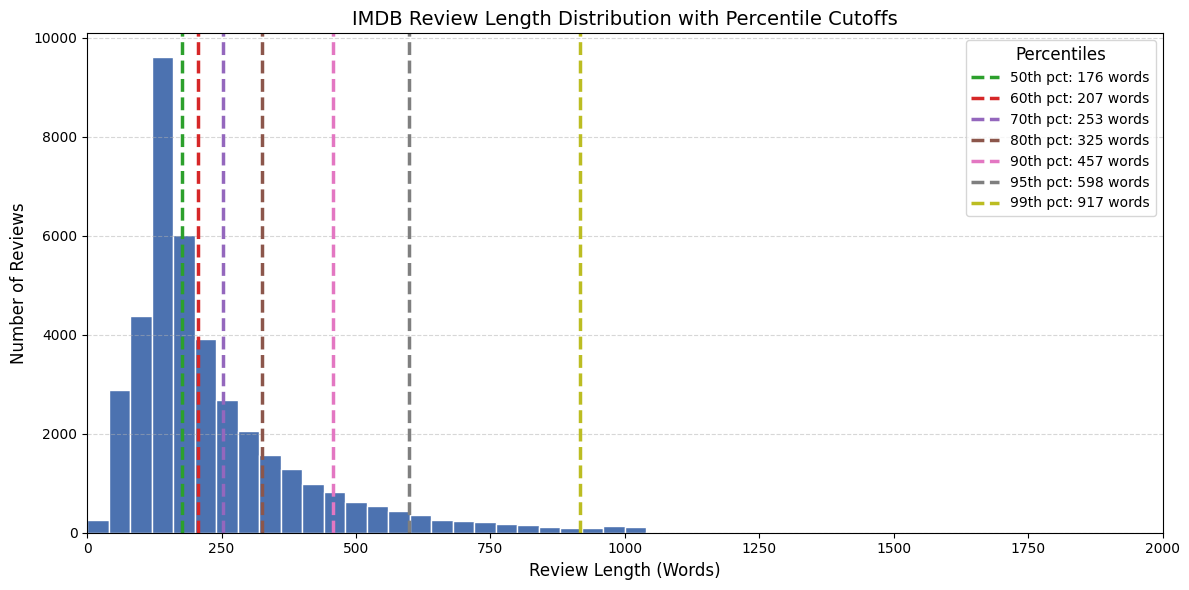

In [14]:
# Convert to numpy array
lengths = np.array(train_sequence_lengths)

plt.figure(figsize=(12, 6))

# cutting off at 2000 for visual clarity on the x-axis
max_x = 2000

# Plot the distribution
plt.hist(
    lengths,
    bins=50,
    range=(0, max_x),
    color="#4C72B0",
    edgecolor="white",
)

# The percentiles to track
percentiles = [50, 60, 70, 80, 90, 95, 99]

# A readable color palette for the vertical lines
colors = ["#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22"]

# Plot a vertical line for each percentile
for p, color in zip(percentiles, colors, strict=False):
    val = np.percentile(lengths, p)
    plt.axvline(
        val,
        color=color,
        linestyle="--",
        linewidth=2.5,
        label=f"{p}th pct: {int(val)} words",
    )

# Formatting
plt.title("IMDB Review Length Distribution with Percentile Cutoffs", fontsize=14)
plt.xlabel("Review Length (Words)", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)
plt.xlim(0, max_x)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Place the legend cleanly outside or in the upper right
plt.legend(title="Percentiles", fontsize=10, title_fontsize=12, loc="upper right")
plt.tight_layout()

plt.show()

The distribution is right skewed, 95th percentile is too many. I would base my guess at the 80th (325 words). To round and stay more optima: 300 words.

In [15]:
MAX_LENGTH = 300 # max length of a sequence

### Padding and Truncating

1. To make the batches of the same size (to make matrix multiplication operations possible by having rectangular matrices), we pad the sequences that are too short with $0$s until they reach `MAX_LENGTH`.

2. Pre-padding (`padding="pre"`) is chosen for more than just an industry standard. The `mask_zero` parameter in an `Embedding` layer ignores $0$s regardless of what type of `padding` we use, *BUT* (and it comes from LSTM's docstring in Keras): cuDNN fast path *on PyTorch back-end* requires **`keras.Embedding(mask_zero=False))`**. Therefore, we have to use **pre-padding** then with `mask_zero` set to `False` to keep the fast GPU.

    **Note**: because the baseline (GAP) would be averaging padding $0$s, and SimpleRNN isn't parallelized on GPU anyway (we need the output of the previous step first), we still set **`keras.Embedding(mask_zero=True))`** for those.

3. For `truncating="pre"`, it is also a standard because most of the context opens towards the end of the delivery. For example, beginning: "I went to see this movie on a Tuesday with my friends. The theater was cold. The director is known for his previous work on...", the end: "...but none of that mattered because the acting was terrible and the plot made no sense. Overall, a complete waste of time. I hated it.".

In [16]:
# 0=<PAD>, 1=<START>, 2=<OOV>, real words from 3 up
x_train = keras.utils.pad_sequences(x_train, maxlen=MAX_LENGTH, padding="pre", truncating="pre")
x_val = keras.utils.pad_sequences(x_val, maxlen=MAX_LENGTH, padding="pre", truncating="pre")
x_test  = keras.utils.pad_sequences(x_test,  maxlen=MAX_LENGTH, padding="pre", truncating="pre")

In [17]:
x_train[0]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

## Data Representation

In [17]:
class IMDBDataset(Dataset):
    def __init__(self, sequences, labels):
        # int32 for the embedding lookup (they're indices, not values to do math on)
        self.sequences = torch.tensor(sequences, dtype=torch.int32)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

train_ds = IMDBDataset(x_train, y_train)
val_ds = IMDBDataset(x_val, y_val)
test_ds = IMDBDataset(x_test, y_test)

### Creating and testing loaders

In [18]:
def build_loaders(batch_size: int, shuffle: bool, generator):
    tr_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=shuffle, generator=generator)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    return tr_loader, val_loader

BATCH_SIZE = 64 # arbitrary
train_loader, val_loader = build_loaders(batch_size=BATCH_SIZE, shuffle=True, generator=torch_gen)

In [19]:
# DataLoaders testing
images_batch, targets_batch = next(iter(train_loader))

print("Images batch shape :", images_batch.shape)
print("Targets batch shape:", targets_batch.shape)
print("Images data type   :", images_batch.dtype)
print("Targets data type  :", targets_batch.dtype)
print("Targets in batch   :", targets_batch)

Images batch shape : torch.Size([64, 300])
Targets batch shape: torch.Size([64])
Images data type   : torch.int32
Targets data type  : torch.float32
Targets in batch   : tensor([1., 1., 1., 0., 1., 0., 0., 0., 0., 0., 1., 1., 0., 0., 1., 0., 1., 0.,
        1., 1., 1., 0., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 1.,
        1., 1., 1., 1., 1., 0., 1., 1., 1., 0., 0., 0., 1., 0., 1., 0., 1., 0.,
        1., 1., 1., 1., 0., 1., 1., 1., 0., 1.])


## Model architecting

### Choosing EMBED_DIM

As mentioned in the "Choosing VOCAB_SIZE" section, we fix it at only adjust if the model underfits. Embedding dimensions to choose from come in a standard ladder: 32, 64, 128, 256. 

Pre-trained models are not even considered here, the task is too simple.

In [20]:
EMBED_DIM = 32
NUM_UNITS = 64 # hold constant for a fair model comparison

### Time calculation

Different architectures, based on their tuned optimizers and parameters might take more or less time. To be fairer with the time comparison, we are going to take the median of 3 epochs of each best model instance and present them in the conclusions.

In [ ]:
class EpochTimer(keras.callbacks.Callback):
    def on_train_begin(self, logs=None): self.times = []                                    # noqa: ARG002
    def on_epoch_begin(self, epoch, logs=None): self._t0 = time.time()                      # noqa: ARG002
    def on_epoch_end(self, epoch, logs=None): self.times.append(time.time() - self._t0)     # noqa: ARG002

### Baseline

As a baseline, we use a simple Logistic Regression and GAP for flattening and generalizing. Not only does it serve as an answer to the simple question of "is it better than a random classifier", it also shows **if word order actually matters for this problem**. If, after training, such a network already results in 88% and LSTM/GRU over this architecture gives 90%, then the actual **order** only gains us so much. It is not worth it. Comparing against this gives real intuitiveness.

In [ ]:
def build_baseline_model():
    return keras.Sequential([
        # 1. Each input sequence is of MAX_LENGTH
        keras.layers.Input(shape=(MAX_LENGTH,), dtype="int32"),                 # int32/64 is standard and keras would cast anything smaller to it anyway

        # 2. EMBEDDING: (BATCH_SIZE, MAX_LENGTH) -> (BATCH_SIZE, MAX_LENGTH, EMBED_DIM) - represents each word as an EMBED_DIM vector
        keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True),      # mask_zero=True, but we still need to skip math not to average the paddings

        # 2. FLATTEN VIA AVERAGE across columns (embedding dims): (BATCH_SIZE, MAX_LENGTH, EMBED_DIM) -> (BATCH_SIZE, EMBED_DIM)
        keras.layers.GlobalAveragePooling1D(),

        # 3. BINARY CLASSIFICATION via Logistic Regression: (BATCH_SIZE, EMBED_DIM) -> (BATCH_SIZE, 1)
        keras.layers.Dense(1, activation="sigmoid"),
    ])

baseline_model = build_baseline_model()
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,033 (1.22 MB)

 Trainable params: 320,033 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

#### Tuning

In [ ]:
def build_rand_search_baseline_model(hp):
    keras.utils.set_random_seed(RANDOM_SEED)    # same init for every trial
    torch_gen.manual_seed(RANDOM_SEED)          # same shuffle order for every trial

    # Define the hyperparameters
    mdl = build_baseline_model()

    lr = hp.Choice("lr", values=[1e-5, 1e-4, 1e-3, 1e-2])                       # 4 options
    optimizer_name = hp.Choice("optimizer", values=["adam", "sgd", "rmsprop"])  # 3 options

    if optimizer_name == "adam":
        optimizer_obj = keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0)
    elif optimizer_name == "sgd":
        optimizer_obj = keras.optimizers.SGD(learning_rate=lr, momentum=0.9, clipnorm=1.0)
    elif optimizer_name == "rmsprop":
        optimizer_obj = keras.optimizers.RMSprop(learning_rate=lr, clipnorm=1.0)

    mdl.compile(
        optimizer=optimizer_obj,
        loss="binary_crossentropy",
        metrics=["binary_accuracy"],
    )
    return mdl

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

train_loader, valid_loader = build_loaders(batch_size=BATCH_SIZE, shuffle=True, generator=torch_gen)

tuner = kt.RandomSearch(
    build_rand_search_baseline_model,
    objective=kt.Objective("val_binary_accuracy", direction="max"),
    max_trials=15,
    directory="1_baseline_tuning",
    project_name="RNNs",
    seed=RANDOM_SEED,
    overwrite=True,                             # start with fresh folder (first tuning run) in /1_baseline_tuning/RNNs/
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,
    epochs=20,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 11 Complete [00h 01m 27s]
val_binary_accuracy: 0.8888000249862671

Best val_binary_accuracy So Far: 0.8988000154495239
Total elapsed time: 00h 34m 15s
{'lr': 0.001, 'optimizer': 'adam'}


In [45]:
debug_tuner(tuner)

,trial_id,score,best_epoch,lr,optimizer
0,00,0.8988,8,0.00100,adam
3,03,0.8916,1,0.01000,adam
10,10,0.8888,5,0.01000,rmsprop
6,06,0.8882,20,0.00100,rmsprop
1,01,0.8680,20,0.00010,adam
7,07,0.7854,20,0.00010,rmsprop
5,05,0.7676,20,0.00001,adam
2,02,0.7316,20,0.01000,sgd
9,09,0.6484,20,0.00001,rmsprop
4,04,0.5554,19,0.00010,sgd


#### Best baseline and timing

In [ ]:
def build_best_baseline_model():
    keras.utils.set_random_seed(RANDOM_SEED)
    torch_gen.manual_seed(RANDOM_SEED)

    # Define the hyperparameters
    mdl = build_baseline_model()

    mdl.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
        loss="binary_crossentropy",
        metrics=["binary_accuracy"],
    )
    return mdl

In [81]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

timer = EpochTimer()
train_loader, valid_loader = build_loaders(batch_size=BATCH_SIZE, shuffle=True, generator=torch_gen)
model = build_best_baseline_model()

model.fit(
    x=train_loader,
    validation_data=valid_loader,
    epochs=3,
    callbacks=[timer],
    verbose=1,
    shuffle=False,
)

print()
print(f"{np.median(timer.times):.1f} s/epoch")

Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - binary_accuracy: 0.7280 - loss: 0.6213 - val_binary_accuracy: 0.8162 - val_loss: 0.5178
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - binary_accuracy: 0.8507 - loss: 0.4352 - val_binary_accuracy: 0.8628 - val_loss: 0.3793
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - binary_accuracy: 0.8801 - loss: 0.3376 - val_binary_accuracy: 0.8740 - val_loss: 0.3225
7.3 s/epoch


#### Evaluation

Restoring the best model from the tuner and evaluating:

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

tuner = kt.RandomSearch(
    build_rand_search_baseline_model,
    objective=kt.Objective("val_binary_accuracy", direction="max"),
    max_trials=15,
    directory="1_baseline_tuning",
    project_name="RNNs",
    seed=RANDOM_SEED,
    overwrite=False,          # must be False, or it wipes the folder
)
tuner.reload()

best_baseline_model = tuner.get_best_models(1)[0]
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loss, test_acc = best_baseline_model.evaluate(test_loader, verbose=1)

print("\n" + "="*40)
print(f"FINAL TEST ACCURACY: {test_acc * 100:.2f}%")
print(f"FINAL TEST LOSS:     {test_loss:.4f}")
print("="*40)

Reloading Tuner from 1_baseline_tuning\RNNs\tuner0.json
 9/79 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - binary_accuracy: 0.8837 - loss: 0.2915

c:\Users\Yur4ik\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 8 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - binary_accuracy: 0.8950 - loss: 0.2627

FINAL TEST ACCURACY: 89.50%
FINAL TEST LOSS:     0.2627


#### Save/load the best model

In [ ]:
# --- Save ---
best_baseline_model.save("best_baseline_GAP_model.keras")

# --- Load ---
loaded = keras.models.load_model("best_baseline_GAP_model.keras")

## Comparing architectures

### SimpleRNN

In [26]:
def build_simple_rnn_model(spatial_dropout_rate: float, dropout_rate: float):
    return keras.Sequential([
        keras.layers.Input(shape=(MAX_LENGTH,), dtype="int32"),
        keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True), # mask_zero makes no difference here because SimpleRNNs are not parallelized on GPU anyway

        keras.layers.SpatialDropout1D(spatial_dropout_rate),
        keras.layers.SimpleRNN(units=NUM_UNITS),

        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(1, activation="sigmoid"),
    ])

simple_rnn_model = build_simple_rnn_model(spatial_dropout_rate=0.0, dropout_rate=0.0)
simple_rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 300, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 300, 32)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 326,273 (1.24 MB)

 Trainable params: 326,273 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

#### Tuning

- SGD showed itself too badly, we're not considering it
- we are fixing the unit count to 64 for a fair comparison across models
- because simple RNNs are incredible slow because they can't be parallelized on GPU. We know theoretically that they barely remember 10-20 timesteps, our `MAX_LENGTH` is 300. We therefore drastically decrease the number of options, epochs and patience. We just need a few numbers for the report to confirm.

In [ ]:
def build_rand_search_simple_rnn_model(hp):
    keras.utils.set_random_seed(RANDOM_SEED)
    torch_gen.manual_seed(RANDOM_SEED)

    # Define the hyperparameters
    dropout_rate = hp.Choice("dropout_rate", values=[0.0, 0.1])
    spatial_dropout_rate = hp.Choice("spatial_dropout_rate", values=[0.0, 0.1])

    mdl = build_simple_rnn_model(spatial_dropout_rate=spatial_dropout_rate, dropout_rate=dropout_rate)

    lr = hp.Choice("lr", values=[1e-3, 1e-2])
    optimizer_name = hp.Choice("optimizer", values=["adam", "rmsprop"])

    if optimizer_name == "adam":
        optimizer_obj = keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0)
    elif optimizer_name == "rmsprop":
        optimizer_obj = keras.optimizers.RMSprop(learning_rate=lr, clipnorm=1.0)

    mdl.compile(
        optimizer=optimizer_obj,
        loss="binary_crossentropy",
        metrics=["binary_accuracy"],
    )
    return mdl

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

train_loader, valid_loader = build_loaders(batch_size=BATCH_SIZE, shuffle=True, generator=torch_gen)

tuner = kt.RandomSearch(
    build_rand_search_simple_rnn_model,
    objective=kt.Objective("val_binary_accuracy", direction="max"),
    max_trials=10,
    directory="2_simple_rnn_tuning",
    project_name="RNNs",
    seed=RANDOM_SEED,
    overwrite=True,                             # start with fresh folder in /2_simple_rnn_tuning/RNN
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 10 Complete [00h 15m 35s]
val_binary_accuracy: 0.73580002784729

Best val_binary_accuracy So Far: 0.868399977684021
Total elapsed time: 03h 14m 35s
{'dropout_rate': 0.0, 'spatial_dropout_rate': 0.0, 'lr': 0.001, 'optimizer': 'rmsprop'}


In [ ]:
debug_tuner(tuner)

,trial_id,score,best_epoch,dropout_rate,spatial_dropout_rate,lr,optimizer
5,05,0.8684,5,0.0,0.0,0.001,rmsprop
3,03,0.8622,2,0.1,0.0,0.001,rmsprop
6,06,0.8498,3,0.1,0.1,0.001,adam
0,00,0.8424,3,0.1,0.0,0.001,adam
2,02,0.7474,5,0.0,0.0,0.010,rmsprop
9,09,0.7358,2,0.1,0.1,0.010,adam
8,08,0.7280,3,0.0,0.1,0.010,adam
7,07,0.7252,6,0.0,0.1,0.010,rmsprop
1,01,0.7010,2,0.1,0.0,0.010,adam
4,04,0.6842,3,0.0,0.0,0.010,adam


#### Best SimpleRNN model and timing

In [ ]:
def build_best_simple_rnn_model():
    keras.utils.set_random_seed(RANDOM_SEED)
    torch_gen.manual_seed(RANDOM_SEED)

    mdl = build_simple_rnn_model(spatial_dropout_rate=0.0, dropout_rate=0.0)

    mdl.compile(
        optimizer=keras.optimizers.RMSprop(learning_rate=0.001, clipnorm=1.0),
        loss="binary_crossentropy",
        metrics=["binary_accuracy"],
    )
    return mdl

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

timer = EpochTimer()
train_loader, valid_loader = build_loaders(batch_size=BATCH_SIZE, shuffle=True, generator=torch_gen)
model = build_best_simple_rnn_model()

model.fit(
    x=train_loader,
    validation_data=valid_loader,
    epochs=3,
    callbacks=[timer],
    verbose=1,
    shuffle=False,
)

print(f"{np.median(timer.times):.1f} s/epoch")

Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 333s 532ms/step - binary_accuracy: 0.7314 - loss: 0.5210 - val_binary_accuracy: 0.8326 - val_loss: 0.3905
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 316s 506ms/step - binary_accuracy: 0.8516 - loss: 0.3550 - val_binary_accuracy: 0.8554 - val_loss: 0.3529
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 317s 507ms/step - binary_accuracy: 0.8763 - loss: 0.3128 - val_binary_accuracy: 0.8538 - val_loss: 0.3545
316.9 s/epoch


#### Evaluation

Restoring the best model manually (didn't save the tuning folder) so the best score will be different because there's no tuner state anymore:

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

train_loader, valid_loader = build_loaders(batch_size=BATCH_SIZE, shuffle=True, generator=torch_gen)
best_simple_rnn_model = build_best_simple_rnn_model()

history = best_simple_rnn_model.fit(
    x=train_loader,
    validation_data=valid_loader,
    epochs=10,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True, verbose=1),
    ],
    verbose=1,
    shuffle=False,
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 325s 521ms/step - binary_accuracy: 0.7314 - loss: 0.5210 - val_binary_accuracy: 0.8326 - val_loss: 0.3905
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 306s 489ms/step - binary_accuracy: 0.8516 - loss: 0.3550 - val_binary_accuracy: 0.8554 - val_loss: 0.3529
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 306s 489ms/step - binary_accuracy: 0.8763 - loss: 0.3128 - val_binary_accuracy: 0.8538 - val_loss: 0.3545
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 305s 489ms/step - binary_accuracy: 0.8923 - loss: 0.2789 - val_binary_accuracy: 0.8784 - val_loss: 0.3328
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 314s 503ms/step - binary_accuracy: 0.8993 - loss: 0.2626 - val_binary_accuracy: 0.8778 - val_loss: 0.3074
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 324s 518ms/step - binary_accuracy: 0.9048 - loss: 0.2436 - val_binary_accuracy: 0.8402 - val_loss: 0.3812
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 328s 526ms/step - binary_accuracy: 0.9058 - loss: 0.2423 - val_binary_accuracy: 0.85

Smoothed scores over epochs grouped by folds:
Epoch  0: train_loss=0.5210  val_loss=0.3905  train_acc=0.7314  val_acc=0.8326
Epoch  1: train_loss=0.3550  val_loss=0.3529  train_acc=0.8516  val_acc=0.8554
Epoch  2: train_loss=0.3128  val_loss=0.3545  train_acc=0.8763  val_acc=0.8538
Epoch  3: train_loss=0.2789  val_loss=0.3328  train_acc=0.8923  val_acc=0.8784
Epoch  4: train_loss=0.2626  val_loss=0.3074  train_acc=0.8993  val_acc=0.8778
Epoch  5: train_loss=0.2436  val_loss=0.3812  train_acc=0.9048  val_acc=0.8402
Epoch  6: train_loss=0.2423  val_loss=0.3498  train_acc=0.9058  val_acc=0.8576



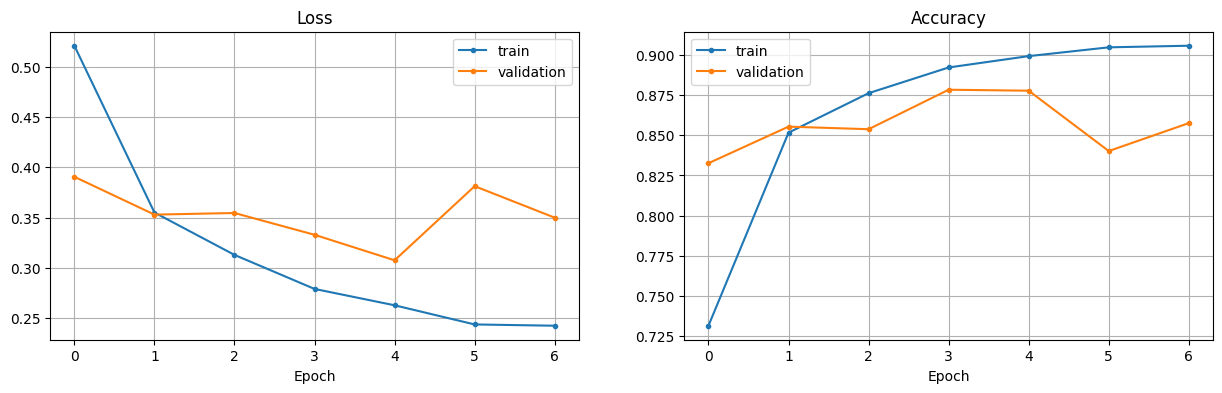

In [28]:
plot_loss_acc_per_ep(history.history["loss"],     history.history["val_loss"],
                     history.history["binary_accuracy"], history.history["val_binary_accuracy"])

In [30]:
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loss, test_acc = best_simple_rnn_model.evaluate(test_loader, verbose=1)

print("\n" + "="*40)
print(f"FINAL TEST ACCURACY: {test_acc * 100:.2f}%")
print(f"FINAL TEST LOSS:     {test_loss:.4f}")
print("="*40)

79/79 ━━━━━━━━━━━━━━━━━━━━ 23s 294ms/step - binary_accuracy: 0.8876 - loss: 0.2922

FINAL TEST ACCURACY: 88.76%
FINAL TEST LOSS:     0.2922


Even worse than logistic regression, must be the vanishing gradient problem that makes an impression of ordering not having any meaning in this task. Simple RNNs can't hold more than 10-20 steps to make a difference and they are terribly slow.

#### Save/load the best model

In [ ]:
# --- Save ---
best_simple_rnn_model.save("best_simple_rnn_model.keras")

# --- Load ---
loaded = keras.models.load_model("best_simple_rnn_model.keras")

### LSTM

In [31]:
def build_lstm_model(spatial_dropout_rate: float, dropout_rate: float):
    return keras.Sequential([
        keras.layers.Input(shape=(MAX_LENGTH,), dtype="int32"),
        keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=False), # mask_zero=False is must-have to fast GPU computation

        keras.layers.SpatialDropout1D(spatial_dropout_rate),
        keras.layers.LSTM(units=NUM_UNITS),

        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(1, activation="sigmoid"),
    ])

lstm_model = build_lstm_model(spatial_dropout_rate=0.0, dropout_rate=0.0)
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 300, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 300, 32)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 344,897 (1.32 MB)

 Trainable params: 344,897 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

#### Tuning

In [ ]:
def build_rand_search_lstm_model(hp):
    keras.utils.set_random_seed(RANDOM_SEED)
    torch_gen.manual_seed(RANDOM_SEED)

    # Define the hyperparameters
    dropout_rate = hp.Choice("dropout_rate", values=[0.0, 0.1])
    spatial_dropout_rate = hp.Choice("spatial_dropout_rate", values=[0.0, 0.1])

    mdl = build_lstm_model(spatial_dropout_rate=spatial_dropout_rate, dropout_rate=dropout_rate)

    lr = hp.Choice("lr", values=[1e-4, 1e-3, 1e-2])
    optimizer_name = hp.Choice("optimizer", values=["adam", "rmsprop"])

    if optimizer_name == "adam":
        optimizer_obj = keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0)
    elif optimizer_name == "rmsprop":
        optimizer_obj = keras.optimizers.RMSprop(learning_rate=lr, clipnorm=1.0)

    mdl.compile(
        optimizer=optimizer_obj,
        loss="binary_crossentropy",
        metrics=["binary_accuracy"],
    )
    return mdl

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

train_loader, valid_loader = build_loaders(batch_size=BATCH_SIZE, shuffle=True, generator=torch_gen)

tuner = kt.RandomSearch(
    build_rand_search_lstm_model,
    objective=kt.Objective("val_binary_accuracy", direction="max"),
    max_trials=16,
    directory="3_lstm_tuning",
    project_name="RNNs",
    seed=RANDOM_SEED,
    overwrite=True,                             # start with fresh folder in /3_lstm_tuning/RNNs/
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,
    epochs=20,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 16 Complete [00h 01m 21s]
val_binary_accuracy: 0.9110000133514404

Best val_binary_accuracy So Far: 0.9110000133514404
Total elapsed time: 00h 32m 09s
{'dropout_rate': 0.1, 'spatial_dropout_rate': 0.1, 'lr': 0.01, 'optimizer': 'rmsprop'}


In [32]:
debug_tuner(tuner)

,trial_id,score,best_epoch,dropout_rate,spatial_dropout_rate,lr,optimizer
15,15,0.9110,3,0.1,0.1,0.0100,rmsprop
12,12,0.9106,3,0.1,0.0,0.0100,rmsprop
10,10,0.9088,3,0.0,0.1,0.0100,rmsprop
1,01,0.9072,4,0.0,0.0,0.0100,rmsprop
11,11,0.9048,2,0.0,0.1,0.0100,adam
6,06,0.9022,3,0.0,0.0,0.0100,adam
2,02,0.9008,2,0.1,0.0,0.0100,adam
14,14,0.8956,8,0.1,0.1,0.0010,rmsprop
5,05,0.8932,14,0.1,0.0,0.0001,rmsprop
7,07,0.8928,5,0.0,0.0,0.0010,rmsprop


- regularization seems to have helped, adding more
- removing adam
- hold lr constant at 0.01
- increasing patience

In [ ]:
def build_rand_search_lstm_model(hp):
    keras.utils.set_random_seed(RANDOM_SEED)
    torch_gen.manual_seed(RANDOM_SEED)

    # Define the hyperparameters
    dropout_rate = hp.Choice("dropout_rate", values=[0.2, 0.3, 0.4])
    spatial_dropout_rate = hp.Choice("spatial_dropout_rate", values=[0.2, 0.3, 0.4])

    mdl = build_lstm_model(spatial_dropout_rate=spatial_dropout_rate, dropout_rate=dropout_rate)

    lr = hp.Choice("lr", values=[1e-2])

    mdl.compile(
        optimizer=keras.optimizers.RMSprop(learning_rate=lr, clipnorm=1.0),
        loss="binary_crossentropy",
        metrics=["binary_accuracy"],
    )
    return mdl

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

train_loader, valid_loader = build_loaders(batch_size=BATCH_SIZE, shuffle=True, generator=torch_gen)

tuner = kt.RandomSearch(
    build_rand_search_lstm_model,
    objective=kt.Objective("val_binary_accuracy", direction="max"),
    max_trials=9,
    directory="3_lstm_tuning_refined",
    project_name="RNNs",
    seed=RANDOM_SEED,
    overwrite=False,                             # start with fresh folder in /3_lstm_tuning_refined/RNNs/ in order to be able to sample from the modified `build_rand_search_lstm_model`
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,
    epochs=20,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)], # more patience
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 9 Complete [00h 02m 32s]
val_binary_accuracy: 0.9110000133514404

Best val_binary_accuracy So Far: 0.9121999740600586
Total elapsed time: 00h 21m 26s
{'dropout_rate': 0.3, 'spatial_dropout_rate': 0.2, 'lr': 0.01}


In [42]:
debug_tuner(tuner)

,trial_id,score,best_epoch,dropout_rate,spatial_dropout_rate,lr
0,0,0.9122,3,0.3,0.2,0.01
7,7,0.9120,3,0.4,0.3,0.01
8,8,0.9110,5,0.3,0.4,0.01
1,1,0.9102,3,0.2,0.4,0.01
6,6,0.9096,6,0.4,0.4,0.01
3,3,0.9086,3,0.2,0.3,0.01
5,5,0.9086,3,0.2,0.2,0.01
4,4,0.9080,5,0.3,0.3,0.01
2,2,0.9078,5,0.4,0.2,0.01


We've only gained so much from additional dropout: 0.9110 -> 0.9122. We have been just extrapolating from noise, such insignificant difference is very unlikely comes from a 10% difference in the dropout probabilities. Just noise across runs, it wasn't the dropout effect.

#### Best LSTM model and timing

In [ ]:
def build_best_lstm_model():
    keras.utils.set_random_seed(RANDOM_SEED)
    torch_gen.manual_seed(RANDOM_SEED)

    mdl = build_lstm_model(spatial_dropout_rate=0.2, dropout_rate=0.3)
    mdl.compile(
        optimizer=keras.optimizers.RMSprop(learning_rate=1e-2, clipnorm=1.0),
        loss="binary_crossentropy",
        metrics=["binary_accuracy"],
    )
    return mdl

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

timer = EpochTimer()
train_loader, valid_loader = build_loaders(batch_size=BATCH_SIZE, shuffle=True, generator=torch_gen)
model = build_best_lstm_model()

model.fit(
    x=train_loader,
    validation_data=valid_loader,
    epochs=3,
    callbacks=[timer],
    verbose=1,
    shuffle=False,
)

print(f"{np.median(timer.times):.1f} s/epoch")

Epoch 1/3
  5/625 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - binary_accuracy: 0.5437 - loss: 0.6901

c:\Users\Yur4ik\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\backend\torch\rnn.py:656: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1481.)
  outputs, h_n, c_n = torch._VF.lstm(


625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - binary_accuracy: 0.7624 - loss: 0.4824 - val_binary_accuracy: 0.8866 - val_loss: 0.2666
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - binary_accuracy: 0.9041 - loss: 0.2447 - val_binary_accuracy: 0.9072 - val_loss: 0.2376
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - binary_accuracy: 0.9300 - loss: 0.1889 - val_binary_accuracy: 0.9122 - val_loss: 0.2232
17.1 s/epoch


#### Evaluation

Restoring the best model from the tuner:

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

tuner = kt.RandomSearch(
    build_rand_search_lstm_model,
    objective=kt.Objective("val_binary_accuracy", direction="max"),
    max_trials=9,
    directory="3_lstm_tuning_refined",
    project_name="RNNs",
    seed=RANDOM_SEED,
    overwrite=False,          # must be False, or it wipes the folder
)
tuner.reload()

In [ ]:
best_lstm_model = tuner.get_best_models(1)[0]
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loss, test_acc = best_lstm_model.evaluate(test_loader, verbose=1)

print("\n" + "="*40)
print(f"FINAL TEST ACCURACY: {test_acc * 100:.2f}%")
print(f"FINAL TEST LOSS:     {test_loss:.4f}")
print("="*40)

Reloading Tuner from 3_lstm_tuning_refined\RNNs\tuner0.json
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - binary_accuracy: 0.9088 - loss: 0.2415

FINAL TEST ACCURACY: 90.88%
FINAL TEST LOSS:     0.2415


#### Save/load the best model

In [ ]:
# --- Save ---
best_lstm_model.save("best_lstm_model.keras")

# --- Load ---
loaded = keras.models.load_model("best_lstm_model.keras")

### GRU

In [105]:
def build_gru_model(spatial_dropout_rate: float, dropout_rate: float):
    return keras.Sequential([
        keras.layers.Input(shape=(MAX_LENGTH,), dtype="int32"),
        keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=False), # mask_zero=False is must-have to fast GPU computation

        keras.layers.SpatialDropout1D(spatial_dropout_rate),
        keras.layers.GRU(units=NUM_UNITS),

        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(1, activation="sigmoid"),
    ])

gru_model = build_gru_model(spatial_dropout_rate=0.0, dropout_rate=0.0)
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 300, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 300, 32)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 64)             │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 338,881 (1.29 MB)

 Trainable params: 338,881 (1.29 MB)

 Non-trainable params: 0 (0.00 B)

#### Tuning

In [ ]:
def build_rand_search_gru_model(hp):
    keras.utils.set_random_seed(RANDOM_SEED)
    torch_gen.manual_seed(RANDOM_SEED)

    # Define the hyperparameters
    dropout_rate = hp.Choice("dropout_rate", values=[0.0, 0.1])
    spatial_dropout_rate = hp.Choice("spatial_dropout_rate", values=[0.0, 0.1])

    mdl = build_gru_model(spatial_dropout_rate=spatial_dropout_rate, dropout_rate=dropout_rate)

    lr = hp.Choice("lr", values=[1e-4, 1e-3, 1e-2])
    optimizer_name = hp.Choice("optimizer", values=["adam", "rmsprop"])

    if optimizer_name == "adam":
        optimizer_obj = keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0)
    elif optimizer_name == "rmsprop":
        optimizer_obj = keras.optimizers.RMSprop(learning_rate=lr, clipnorm=1.0)

    mdl.compile(
        optimizer=optimizer_obj,
        loss="binary_crossentropy",
        metrics=["binary_accuracy"],
    )
    return mdl

In [35]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

train_loader, valid_loader = build_loaders(batch_size=BATCH_SIZE, shuffle=True, generator=torch_gen)

tuner = kt.RandomSearch(
    build_rand_search_gru_model,
    objective=kt.Objective("val_binary_accuracy", direction="max"),
    max_trials=16,
    directory="4_gru_tuning",
    project_name="RNNs",
    seed=RANDOM_SEED,
    overwrite=True,                             # start with fresh folder in /4_gru_tuning/RNNs/
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,
    epochs=20,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 16 Complete [00h 01m 41s]
val_binary_accuracy: 0.9146000146865845

Best val_binary_accuracy So Far: 0.9146000146865845
Total elapsed time: 00h 30m 08s
{'dropout_rate': 0.1, 'spatial_dropout_rate': 0.1, 'lr': 0.01, 'optimizer': 'rmsprop'}


In [77]:
debug_tuner(tuner=tuner)

,trial_id,score,dropout_rate,spatial_dropout_rate,lr,optimizer,train_binary_accuracy,train_loss,val_binary_accuracy,val_loss,best_epoch
0,15,0.9146,0.1,0.1,0.0100,rmsprop,0.942625,0.158123,0.9146,0.228896,3
1,10,0.9124,0.0,0.1,0.0100,rmsprop,0.943025,0.153470,0.9124,0.229936,3
2,01,0.9112,0.0,0.0,0.0100,rmsprop,0.945125,0.149781,0.9112,0.237714,3
3,12,0.9110,0.1,0.0,0.0100,rmsprop,0.945925,0.149688,0.9110,0.233144,3
4,06,0.9096,0.0,0.0,0.0100,adam,0.844375,0.341504,0.9096,0.218390,1
5,11,0.9088,0.0,0.1,0.0100,adam,0.934550,0.173215,0.9088,0.235905,2
6,02,0.9078,0.1,0.0,0.0100,adam,0.935925,0.171857,0.9078,0.231873,2
7,14,0.9020,0.1,0.1,0.0010,rmsprop,0.954675,0.130158,0.9020,0.264313,9
8,04,0.9018,0.1,0.0,0.0010,rmsprop,0.940900,0.162385,0.9018,0.238384,6
9,07,0.8982,0.0,0.0,0.0010,rmsprop,0.937575,0.171322,0.8982,0.252314,6


#### Best GRU model and timing

In [ ]:
def build_best_gru_model():
    keras.utils.set_random_seed(RANDOM_SEED)
    torch_gen.manual_seed(RANDOM_SEED)

    mdl = build_gru_model(spatial_dropout_rate=0.1, dropout_rate=0.1)
    mdl.compile(
        optimizer=keras.optimizers.RMSprop(learning_rate=1e-2, clipnorm=1.0),
        loss="binary_crossentropy",
        metrics=["binary_accuracy"],
    )
    return mdl

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

timer = EpochTimer()
train_loader, valid_loader = build_loaders(batch_size=BATCH_SIZE, shuffle=True, generator=torch_gen)
model = build_best_gru_model()

model.fit(
    x=train_loader,
    validation_data=valid_loader,
    epochs=3,
    callbacks=[timer],
    verbose=1,
    shuffle=False,
)

print(f"{np.median(timer.times):.1f} s/epoch")

Epoch 1/3
  5/625 ━━━━━━━━━━━━━━━━━━━━ 19s 32ms/step - binary_accuracy: 0.5031 - loss: 0.6956

c:\Users\Yur4ik\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\backend\torch\rnn.py:887: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1481.)
  outputs, h_n = torch._VF.gru(


625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - binary_accuracy: 0.8056 - loss: 0.4099 - val_binary_accuracy: 0.8942 - val_loss: 0.2485
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - binary_accuracy: 0.9177 - loss: 0.2111 - val_binary_accuracy: 0.9076 - val_loss: 0.2294
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - binary_accuracy: 0.9426 - loss: 0.1581 - val_binary_accuracy: 0.9146 - val_loss: 0.2289
16.3 s/epoch


#### Evaluation

Restoring the best model from the tuner:

In [82]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

tuner = kt.RandomSearch(
    build_rand_search_gru_model,
    objective=kt.Objective("val_binary_accuracy", direction="max"),
    max_trials=16,
    directory="4_gru_tuning",
    project_name="RNNs",
    seed=RANDOM_SEED,
    overwrite=False,          # must be False, or it wipes the folder
)
tuner.reload()

Reloading Tuner from 4_gru_tuning\RNNs\tuner0.json


In [83]:
best_gru_model = tuner.get_best_models(1)[0]
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loss, test_acc = best_gru_model.evaluate(test_loader, verbose=1)

print("\n" + "="*40)
print(f"FINAL TEST ACCURACY: {test_acc * 100:.2f}%")
print(f"FINAL TEST LOSS:     {test_loss:.4f}")
print("="*40)

c:\Users\Yur4ik\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'rm_sprop', because it has 2 variables whereas the saved optimizer has 8 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


14/79 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - binary_accuracy: 0.9129 - loss: 0.2468

c:\Users\Yur4ik\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\backend\torch\rnn.py:887: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1481.)
  outputs, h_n = torch._VF.gru(


79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - binary_accuracy: 0.9120 - loss: 0.2416

FINAL TEST ACCURACY: 91.20%
FINAL TEST LOSS:     0.2416


Since there was virtually no difference between GRU and LSTM for this task, we are going to use GRU in bidirectional and deep architectures for the sake of speed.

#### Save/load the best model

In [ ]:
# --- Save ---
best_gru_model.save("best_gru_model.keras")

# --- Load ---
loaded = keras.models.load_model("best_gru_model.keras")

### Bidirectional GRU

In [106]:
def build_bidirectional_gru_model(spatial_dropout_rate: float, dropout_rate: float):
    return keras.Sequential([
        keras.layers.Input(shape=(MAX_LENGTH,), dtype="int32"),
        keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=False), # mask_zero=False is must-have to fast GPU computation

        keras.layers.SpatialDropout1D(spatial_dropout_rate),
        keras.layers.Bidirectional(keras.layers.GRU(units=NUM_UNITS)),

        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(1, activation="sigmoid"),
    ])

bidirectional_gru_model = build_bidirectional_gru_model(spatial_dropout_rate=0.0, dropout_rate=0.0)
bidirectional_gru_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 300, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, 300, 32)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        37,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,761 (1.36 MB)

 Trainable params: 357,761 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

#### Tuning

In [ ]:
def build_rand_search_bidirectional_gru_model(hp):
    keras.utils.set_random_seed(RANDOM_SEED)
    torch_gen.manual_seed(RANDOM_SEED)

    # Define the hyperparameters
    dropout_rate = hp.Choice("dropout_rate", values=[0.0, 0.1])
    spatial_dropout_rate = hp.Choice("spatial_dropout_rate", values=[0.0, 0.1])

    mdl = build_bidirectional_gru_model(spatial_dropout_rate=spatial_dropout_rate, dropout_rate=dropout_rate)

    lr = hp.Choice("lr", values=[1e-4, 1e-3, 1e-2])
    optimizer_name = hp.Choice("optimizer", values=["adam", "rmsprop"])

    if optimizer_name == "adam":
        optimizer_obj = keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0)
    elif optimizer_name == "rmsprop":
        optimizer_obj = keras.optimizers.RMSprop(learning_rate=lr, clipnorm=1.0)

    mdl.compile(
        optimizer=optimizer_obj,
        loss="binary_crossentropy",
        metrics=["binary_accuracy"],
    )
    return mdl

In [87]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

train_loader, valid_loader = build_loaders(batch_size=BATCH_SIZE, shuffle=True, generator=torch_gen)

tuner = kt.RandomSearch(
    build_rand_search_bidirectional_gru_model,
    objective=kt.Objective("val_binary_accuracy", direction="max"),
    max_trials=16,
    directory="5_bidirectional_gru_tuning",
    project_name="RNNs",
    seed=RANDOM_SEED,
    overwrite=True,                             # start with fresh folder in /5_bidirectional_gru_tuning/RNNs/
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,
    epochs=20,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 16 Complete [00h 02m 27s]
val_binary_accuracy: 0.9074000120162964

Best val_binary_accuracy So Far: 0.9129999876022339
Total elapsed time: 00h 42m 03s
{'dropout_rate': 0.0, 'spatial_dropout_rate': 0.1, 'lr': 0.01, 'optimizer': 'rmsprop'}


In [88]:
debug_tuner(tuner)

,trial_id,score,dropout_rate,spatial_dropout_rate,lr,optimizer,train_binary_accuracy,train_loss,val_binary_accuracy,val_loss,best_epoch
0,10,0.9130,0.0,0.1,0.0100,rmsprop,0.939125,0.161117,0.9130,0.225019,3
1,11,0.9106,0.0,0.1,0.0100,adam,0.928075,0.189947,0.9106,0.232409,2
2,01,0.9088,0.0,0.0,0.0100,rmsprop,0.946250,0.149725,0.9088,0.228513,3
3,12,0.9082,0.1,0.0,0.0100,rmsprop,0.943225,0.154724,0.9082,0.237474,3
4,15,0.9074,0.1,0.1,0.0100,rmsprop,0.956550,0.122408,0.9074,0.239115,4
5,06,0.9064,0.0,0.0,0.0100,adam,0.843075,0.341836,0.9064,0.227302,1
6,02,0.9058,0.1,0.0,0.0100,adam,0.936300,0.170863,0.9058,0.237805,2
7,04,0.9016,0.1,0.0,0.0010,rmsprop,0.936350,0.173368,0.9016,0.244329,6
8,14,0.9000,0.1,0.1,0.0010,rmsprop,0.941550,0.161312,0.9000,0.250504,7
9,07,0.8996,0.0,0.0,0.0010,rmsprop,0.938575,0.168100,0.8996,0.241492,6


#### Best bidirectional GRU and timing

In [ ]:
def build_best_bidirectional_gru_model():
    keras.utils.set_random_seed(RANDOM_SEED)
    torch_gen.manual_seed(RANDOM_SEED)

    mdl = build_bidirectional_gru_model(spatial_dropout_rate=0.1, dropout_rate=0.0)

    mdl.compile(
        optimizer=keras.optimizers.RMSprop(learning_rate=1e-2, clipnorm=1.0),
        loss="binary_crossentropy",
        metrics=["binary_accuracy"],
    )
    return mdl

In [93]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

timer = EpochTimer()
train_loader, valid_loader = build_loaders(batch_size=BATCH_SIZE, shuffle=True, generator=torch_gen)
model = build_best_bidirectional_gru_model()

model.fit(
    x=train_loader,
    validation_data=valid_loader,
    epochs=3,
    callbacks=[timer],
    verbose=1,
    shuffle=False,
)

print(f"{np.median(timer.times):.1f} s/epoch")

Epoch 1/3
  3/625 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - binary_accuracy: 0.5104 - loss: 0.6978

c:\Users\Yur4ik\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\backend\torch\rnn.py:1200: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1481.)
  outputs, h_n = torch._VF.gru(


625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - binary_accuracy: 0.7972 - loss: 0.4180 - val_binary_accuracy: 0.8990 - val_loss: 0.2447
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - binary_accuracy: 0.9140 - loss: 0.2160 - val_binary_accuracy: 0.9122 - val_loss: 0.2165
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - binary_accuracy: 0.9391 - loss: 0.1611 - val_binary_accuracy: 0.9130 - val_loss: 0.2250
22.6 s/epoch


#### Evaluation

Restoring the best model from the tuner:

In [94]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

tuner = kt.RandomSearch(
    build_rand_search_bidirectional_gru_model,
    objective=kt.Objective("val_binary_accuracy", direction="max"),
    max_trials=16,
    directory="5_bidirectional_gru_tuning",
    project_name="RNNs",
    seed=RANDOM_SEED,
    overwrite=False,          # must be False, or it wipes the folder
)
tuner.reload()

Reloading Tuner from 5_bidirectional_gru_tuning\RNNs\tuner0.json


In [95]:
best_bidirectional_gru_model = tuner.get_best_models(1)[0]
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loss, test_acc = best_bidirectional_gru_model.evaluate(test_loader, verbose=1)

print("\n" + "="*40)
print(f"FINAL TEST ACCURACY: {test_acc * 100:.2f}%")
print(f"FINAL TEST LOSS:     {test_loss:.4f}")
print("="*40)

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - binary_accuracy: 0.9150 - loss: 0.2319

FINAL TEST ACCURACY: 91.50%
FINAL TEST LOSS:     0.2319


#### Save/load the best model

In [ ]:
# --- Save ---
best_bidirectional_gru_model.save("best_bidirectional_gru_model.keras")

# --- Load ---
loaded = keras.models.load_model("best_bidirectional_gru_model.keras")

### Stacked GRU

In [104]:
def build_stacked_gru_model(spatial_dropout_rate: float, dropout_rate: float):
    return keras.Sequential([
        keras.layers.Input(shape=(MAX_LENGTH,), dtype="int32"),
        keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=False), # mask_zero=False is must-have to fast GPU computation

        keras.layers.SpatialDropout1D(spatial_dropout_rate),
        keras.layers.GRU(units=NUM_UNITS, return_sequences=True),
        keras.layers.GRU(units=NUM_UNITS//2),

        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(1, activation="sigmoid"),
    ])

stacked_gru_model = build_stacked_gru_model(spatial_dropout_rate=0.0, dropout_rate=0.0)
stacked_gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 300, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 300, 32)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 300, 64)        │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 348,257 (1.33 MB)

 Trainable params: 348,257 (1.33 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def build_rand_search_stacked_gru_model(hp):
    keras.utils.set_random_seed(RANDOM_SEED)
    torch_gen.manual_seed(RANDOM_SEED)

    # Define the hyperparameters
    dropout_rate = hp.Choice("dropout_rate", values=[0.0, 0.1])
    spatial_dropout_rate = hp.Choice("spatial_dropout_rate", values=[0.0, 0.1])

    mdl = build_stacked_gru_model(spatial_dropout_rate=spatial_dropout_rate, dropout_rate=dropout_rate)

    lr = hp.Choice("lr", values=[1e-4, 1e-3, 1e-2])
    optimizer_name = hp.Choice("optimizer", values=["adam", "rmsprop"])

    if optimizer_name == "adam":
        optimizer_obj = keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0)
    elif optimizer_name == "rmsprop":
        optimizer_obj = keras.optimizers.RMSprop(learning_rate=lr, clipnorm=1.0)

    mdl.compile(
        optimizer=optimizer_obj,
        loss="binary_crossentropy",
        metrics=["binary_accuracy"],
    )
    return mdl

In [98]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

train_loader, valid_loader = build_loaders(batch_size=BATCH_SIZE, shuffle=True, generator=torch_gen)

tuner = kt.RandomSearch(
    build_rand_search_stacked_gru_model,
    objective=kt.Objective("val_binary_accuracy", direction="max"),
    max_trials=16,
    directory="6_stacked_gru_tuning",
    project_name="RNNs",
    seed=RANDOM_SEED,
    overwrite=True,                             # start with fresh folder in /6_stacked_gru_tuning/RNNs/
)

tuner.search(
    x=train_loader,
    validation_data=valid_loader,
    epochs=20,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1)],
    verbose=1,
    shuffle=False,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

Trial 16 Complete [00h 02m 01s]
val_binary_accuracy: 0.9089999794960022

Best val_binary_accuracy So Far: 0.9115999937057495
Total elapsed time: 00h 35m 37s
{'dropout_rate': 0.0, 'spatial_dropout_rate': 0.1, 'lr': 0.01, 'optimizer': 'rmsprop'}


In [99]:
debug_tuner(tuner)

,trial_id,score,dropout_rate,spatial_dropout_rate,lr,optimizer,train_binary_accuracy,train_loss,val_binary_accuracy,val_loss,best_epoch
0,10,0.9116,0.0,0.1,0.0100,rmsprop,0.943575,0.152636,0.9116,0.229035,3
1,02,0.9106,0.1,0.0,0.0100,adam,0.850900,0.335889,0.9106,0.220114,1
2,12,0.9104,0.1,0.0,0.0100,rmsprop,0.947575,0.147165,0.9104,0.241807,3
3,06,0.9098,0.0,0.0,0.0100,adam,0.931325,0.179512,0.9098,0.237790,2
4,15,0.9090,0.1,0.1,0.0100,rmsprop,0.942550,0.158155,0.9090,0.231828,3
5,11,0.9076,0.0,0.1,0.0100,adam,0.839900,0.349611,0.9076,0.225182,1
6,01,0.9054,0.0,0.0,0.0100,rmsprop,0.920325,0.206022,0.9054,0.235581,2
7,14,0.8990,0.1,0.1,0.0010,rmsprop,0.962075,0.112771,0.8990,0.295637,9
8,04,0.8982,0.1,0.0,0.0010,rmsprop,0.933625,0.178477,0.8982,0.256678,5
9,08,0.8980,0.1,0.1,0.0010,adam,0.932200,0.180964,0.8980,0.252620,3


#### Best stacked GRU and timing

In [ ]:
def build_best_stacked_gru_model():
    keras.utils.set_random_seed(RANDOM_SEED)
    torch_gen.manual_seed(RANDOM_SEED)

    mdl = build_stacked_gru_model(spatial_dropout_rate=0.1, dropout_rate=0.0)

    mdl.compile(
        optimizer=keras.optimizers.RMSprop(learning_rate=1e-2, clipnorm=1.0),
        loss="binary_crossentropy",
        metrics=["binary_accuracy"],
    )
    return mdl

In [101]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

timer = EpochTimer()
train_loader, valid_loader = build_loaders(batch_size=BATCH_SIZE, shuffle=True, generator=torch_gen)
model = build_best_stacked_gru_model()

model.fit(
    x=train_loader,
    validation_data=valid_loader,
    epochs=3,
    callbacks=[timer],
    verbose=1,
    shuffle=False,
)

print(f"{np.median(timer.times):.1f} s/epoch")

Epoch 1/3
  1/625 ━━━━━━━━━━━━━━━━━━━━ 1:35 154ms/step - binary_accuracy: 0.4688 - loss: 0.6930

c:\Users\Yur4ik\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\backend\torch\rnn.py:887: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1481.)
  outputs, h_n = torch._VF.gru(


625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - binary_accuracy: 0.8096 - loss: 0.4020 - val_binary_accuracy: 0.9022 - val_loss: 0.2356
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - binary_accuracy: 0.9192 - loss: 0.2080 - val_binary_accuracy: 0.9098 - val_loss: 0.2280
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - binary_accuracy: 0.9436 - loss: 0.1526 - val_binary_accuracy: 0.9116 - val_loss: 0.2290
21.1 s/epoch


#### Evaluation

Restoring the best model from the tuner:

In [102]:
keras.utils.set_random_seed(RANDOM_SEED)
torch_gen.manual_seed(RANDOM_SEED)
keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

tuner = kt.RandomSearch(
    build_rand_search_stacked_gru_model,
    objective=kt.Objective("val_binary_accuracy", direction="max"),
    max_trials=16,
    directory="6_stacked_gru_tuning",
    project_name="RNNs",
    seed=RANDOM_SEED,
    overwrite=False,          # must be False, or it wipes the folder
)
tuner.reload()

Reloading Tuner from 6_stacked_gru_tuning\RNNs\tuner0.json


In [103]:
best_stacked_gru_model = tuner.get_best_models(1)[0]
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loss, test_acc = best_stacked_gru_model.evaluate(test_loader, verbose=1)

print("\n" + "="*40)
print(f"FINAL TEST ACCURACY: {test_acc * 100:.2f}%")
print(f"FINAL TEST LOSS:     {test_loss:.4f}")
print("="*40)

c:\Users\Yur4ik\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'rm_sprop', because it has 2 variables whereas the saved optimizer has 11 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - binary_accuracy: 0.9100 - loss: 0.2359

FINAL TEST ACCURACY: 91.00%
FINAL TEST LOSS:     0.2359


#### Save/load the best model

In [ ]:
# --- Save ---
best_stacked_gru_model.save("best_stacked_gru_model.keras")

# --- Load ---
loaded = keras.models.load_model("best_stacked_gru_model.keras")

### Conclusion

#### Overview 
The architecture comparison was conducted with the following held constant:

| Constant | Value |
|----------|-------|
|BATCH_SIZE|64|
|EMBED_DIM|32|
|MAX_LENGTH|300|
|VOCAB_SIZE|10,000|
|NUM_UNITS|64|

**NOTES**: 
- Train_time / ep., sec is given across first 3 epochs of every best model.
- The data on some models is not full because I didn't develop full functionality at the time and didn't feel like rerunning a very long training.

The results:

| Architecture      | Optimizer, lr | Regul. | Param_count | Train_time / ep., sec | Best_epoch | Train_acc | Val_acc | Val_loss | Test_accuracy | Test_loss |
|-------------------|---------------|--------|-------------|-----------------------|------------|-----------|---------|----------|---------------|-----------|
|GAP (baseline)      |Adam(1e-3)     |-       |320,033      |7.3                    |8           |-          |0.8988   |-         |0.8950         |0.2627     |
|SimpleRNN           |RMSprop(1e-3)  |Dropout=0.0, SpatialDropout=0.0|326,273      |316.9    |5           |0.8993     |0.8778   |0.3074    |0.8876         |0.2922     |
|LSTM                |RMSprop(1e-2)  |Dropout=0.3, SpatialDropout=0.2|344,897      |17.1    |3           |-          |0.9122   |-         |0.9088         |0.2415     |
|GRU                 |RMSprop(1e-2)  |Dropout=0.1, SpatialDropout=0.1|338,881      |16.3    |3           |0.9426     |0.9146   |0.2289    |0.9120         |0.2416     |
|Bidirectional GRU   |RMSprop(1e-2)  |Dropout=0.0, SpatialDropout=0.1|357,761      |22.6    |3           |0.9391     |0.9130   |0.2250    |0.9150         |0.2319     |
|Stacked GRU         |RMSprop(1e-2)  |Dropout=0.0, SpatialDropout=0.1|348,257      |21.1    |3           |0.9436     |0.9116   |0.2290    |0.9100         |0.2359     |


Selection was performed on validation. Test was evaluated once, after all choices were fixed, it wasn't referenced in any made decision.

#### Why is there no winner

Everything from LSTM upward is between $[0.9088, 0.9150]. This is a gap of ≈$0.0062$. Statistically speaking, it's nothing because the 95% confidence interval:
$$\begin{gather*}
MoE=Z \times \sqrt{\frac{p(1-p)}{n}} \\ \\
\bullet \text{ $Z = 1.96$ (95\% confidence interval)} \\
\bullet \text{ $p = 0.91$ (91\% accuracy)} \\
\bullet \text{ $1-p = 0.09$ (error rate)} \\
\bullet \text{ $n = 5,000$ (test sample size)} \\
\end{gather*}$$

Substitute:
$$MoE=Z \times \sqrt{\frac{p(1-p)}{n}}=1.96 \times \sqrt{\frac{0.91 \times 0.09}{5000}}=1.96 \times \sqrt{0.00001638} \approx 0.0079 \$$

It means that the 95% confidence interval on an accuracy near 91% is about ±0.8 pp, which is wider than the entire spread itself (0.006 pp.). Statistically speaking, we cannot claim that any of the models within the interval is better than another. It is mathematically just as likely that LSTM and Stacked GRU are equally smart, but Bidirectional GRU just got lucky and guessed right on a few borderline reviews in this specific test set.

**Ultimately**, the performance difference between the recurrent architectures is statistically insignificant, as the spread falls entirely within the margin of error of the test set.

#### What we may conclude
What we **may** state, though, is:
- SimpleRNN (88.8%) lost to a model with no recurrence at all (89.5%). It is exactly the vanishing-gradient prediction with MAX_LENGTH=300 and a practical memory of 10–20 steps, the recurrence contributes nothing and costs 316.9 s per epoch — roughly 19x the GRU.
- Gating bought about +2 pp over the bag-of-words baseline (89.5% -> 91.2%)

#### Why is there no winner
IMDB is not suitable for this task. It is mostly a lexical problem. Words themselves ("terrible", "waste", "brilliant" carry nearly all the signal) and the ordering and the ordering gives very little. The small win might be of those with sarcasm or negation ("not great"), could be some region-specific expressions as in Ireland ("not horribly pleasant")

Another reason why the task wrongly chose the data is the absence of punctuation. Yet one more thing where ordering could do something.

I would choose the baseline as a final model, RNNs make no sense here, not for this data.